# Plotting Fit Results and Map from Crab Fit

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rc('axes.formatter', use_mathtext=True)
plt.rcParams['legend.title_fontsize'] = 14
import pickle
from astropy.table import Table
from scipy.interpolate import PchipInterpolator
import sys
sys.path.append('./')
from leptonic_class_naima import *

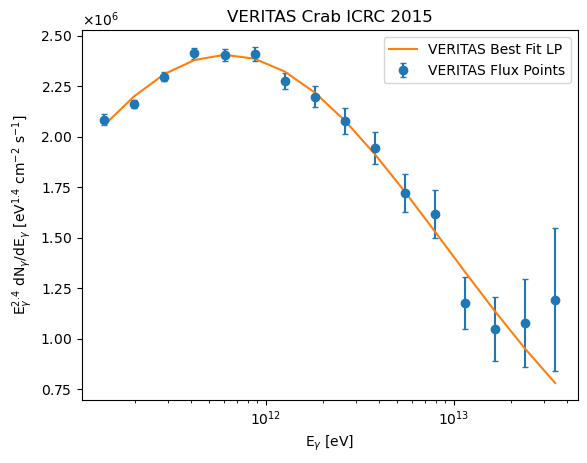

In [2]:
# Gamma-Ray Data
VTS_data = Table.read("VERITAS_2015_ICRC_Crab.ecsv", format="ecsv") # https://doi.org/10.22323/1.236.0792
VTS_xdata = VTS_data["e_ref"] * 1e12 # eV
VTS_ydata = VTS_data["dnde"] / 1e12 # eV-1 cm-2 s-1
VTS_sigma = VTS_data["dnde_err"] / 1e12 # eV-1 cm-2 s-1

E = VTS_xdata
f0 = 3.75e-11 / 1e12 # eV-1 cm-2 s-1
alpha = 2.467
beta = -0.16
E0 = 1e12 # eV

model_y = f0*(E/E0)**(-alpha + (beta*np.log10(E / E0)))

plt.errorbar(VTS_xdata, VTS_ydata * VTS_xdata**2.4, yerr=VTS_sigma * VTS_xdata**2.4, fmt='o', capsize=2, label='VERITAS Flux Points')
plt.plot(VTS_xdata, model_y * VTS_xdata**2.4, label='VERITAS Best Fit LP')
plt.xlabel(r'E$_\gamma$ [eV]')
plt.ylabel(r'E$_\gamma^{2.4}$ dN$_\gamma$/dE$_\gamma$ [eV$^{1.4}$ cm$^{-2}$ s$^{-1}$]')
plt.title('VERITAS Crab ICRC 2015')
plt.legend()
plt.xscale('log')
#plt.yscale('log')
plt.show()

In [ ]:
B = 125 #uG
t_max = 1e3 # 10 kyr

E0s = np.logspace(12, 17, 300) # eV
print('B (µG)    |Ec (PeV)  |Q0        |α         |Le (erg/s) |Chi^2     ')
with open(f'fit_Crab_B{B:.0f}.pkl', 'rb') as file:
    _fit = pickle.load(file)
ts = get_trange(B, t_max)
binwidths = get_binwidths(ts)
_Q0 = _fit.params['Q0'].value
_A = _fit.params['A'].value
Ec = _fit.params['Ec'].value
chisq = _fit.chisqr
ECPL = 10**_Q0 * E0s**(-1 * _A) * np.exp(-1 * E0s / (10**Ec))
e_per = np.trapezoid(ECPL * E0s, E0s)
e_total = 0
for i in binwidths:
    e_total += e_per * i / (t_max * 3.154e7)
e_per_s = e_total / (t_max * 3.154e7) * 1.602e-12 # erg
print(f'{B:.0f}       |{10**Ec / 1e15:.2f}      |{_Q0:.3f}    |{_A:.2f}      |{e_per_s:.3e}  |{chisq:.3f}   ')

In [ ]:
Egs = np.logspace(np.log10(VTS_xdata[0]) - 1, np.log10(VTS_xdata[-1]) + 1, 60)

fig, axs = plt.subplots(1, 1, figsize=(8,6), dpi=150, layout='constrained',sharey=True)

B = 125
with open(f'fit_Crab_B{B:.0f}.pkl', 'rb') as file:
    _fit = pickle.load(file)
_A = _fit.params['A'].value
Ec = _fit.params['Ec'].value
_flux = np.load(f'flux_Crab_A{_A*10:.0f}_Ec{Ec*10:.0f}_B{B:.0f}.npy')
_flux = np.nansum(_flux.transpose(), axis=1)

capsize = 5
ind_1TeV_VTS = np.where(VTS_xdata >= 1e12)[0][0]
ind_1TeV = np.where(Egs >= 1e12)[0][0]
_flux /= _flux[ind_1TeV]
VTS_ydata /= VTS_ydata[ind_1TeV_VTS]

axs.plot(Egs/1e12, _flux * 1e-12 * Egs**2, '-', label=r'$E_c$'+f'={10**Ec/1e15:.2f} PeV, '+r'$\alpha$'+f'={_A:.2f}', color='C0')
axs.errorbar(VTS_xdata/1e12, VTS_ydata * 1e-12 * VTS_xdata**2, yerr=VTS_sigma * 1e-12 * VTS_xdata**2, fmt='o', label='VTS', capsize=capsize, color='C1')

axs.set_ylabel(r'E$^2_\gamma$ $\mathrm{dN}_\gamma/\mathrm{dE}_\gamma$ $\left(\mathrm{TeV}/\mathrm{cm}^2/\mathrm{s}\right)$',fontsize=14)
axs.loglog()
axs.set_xlabel(r'E$_\gamma$ (TeV)',fontsize=14)
axs.legend(fontsize=14)
axs.tick_params(labelsize=14)
fig.show()

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(7,5.8),layout='constrained', sharex=True, sharey=True, dpi=200)

rad_prof = np.load(f'map_Crab_B{B:.0f}.npy') # 1/eV/cm2/s/sr
rad_prof = rad_prof.sum(axis=0)
Egs = np.logspace(np.log10(VTS_xdata[0]) - 1, np.log10(VTS_xdata[-1]) + 1, 60)
thetas = np.linspace(0, 0.5, 20) # degrees
thetas = thetas * np.pi / 180  # convert to radians

# Create splines for each energy across angles from the sources
splines = []
for _flux in rad_prof:
    spl = PchipInterpolator(thetas, _flux) # thetas in radians
    splines.append(spl)
# Create an upsampled 2D grid from the splines and sum
num_points = 100
up_thetas = np.linspace(thetas[0], thetas[-1], num_points)
out_fluxs = np.zeros((len(Egs), num_points*2 - 1, num_points*2 - 1))
for ind, spl in enumerate(splines):
    matrix = np.zeros((num_points, num_points))
    for i in range(num_points):
        for j in range(num_points):
            x = up_thetas[i]
            y = up_thetas[j]
            dist = np.sqrt(x**2 + y**2)
            if dist > up_thetas[-1]:
                matrix[i][j] = 0.0
            else:
                matrix[i][j] = spl(dist)
    quad_3 = matrix
    quad_0 = np.rot90(quad_3)
    quad_1 = np.rot90(quad_0)
    quad_2 = np.rot90(quad_1)
    quad_0 = np.delete(quad_0, -1, 0)
    quad_1 = np.delete(quad_1, -1, 1)
    quad_2 = np.delete(quad_2, 0, 0)
    quad_2 = np.delete(quad_2, -1, 1)
    right = np.vstack((quad_0, quad_3))
    left = np.vstack((quad_1, quad_2))
    all_quad = np.hstack((left, right))
    out_fluxs[ind] = all_quad

# Setting integration bounds in energy for map
lows = [1]
highs = [1000]

for low, high, ind in zip(lows, highs, range(3)):
    int_flux = np.zeros((199, 199))
    for n in range(199):
        for m in range(199):
            interped = np.interp(np.logspace(np.log10(low * 1e12), np.log10(high * 1e12), 200), Egs, out_fluxs[:, n, m])
            int_flux[n][m] = np.trapezoid(interped * np.logspace(np.log10(low * 1e12), np.log10(high * 1e12), 200), np.logspace(np.log10(low * 1e12), np.log10(high * 1e12), 200))
    quad_max, quad_min = np.max(int_flux[int_flux > 0])/1e12, np.min(int_flux[int_flux > 0])/1e12
    
    cax = ax.imshow(int_flux / 1e12, extent=[-1 * thetas[-1] * 180 / np.pi, thetas[-1] * 180 / np.pi, -1 * thetas[-1] * 180 / np.pi, thetas[-1] * 180 / np.pi], origin='lower', cmap='viridis', vmin=quad_min, vmax=quad_max)
    ax.xaxis.set_tick_params(labelsize=14)
    ax.yaxis.set_tick_params(labelsize=14)
    cbar = fig.colorbar(cax, ax=ax, orientation='vertical', shrink=0.8)
    cbar.ax.tick_params(labelsize=14, which='both')
    cbar.set_label(r'Integrated Gamma-Ray Flux $\left(\mathrm{TeV}/\mathrm{cm}^2/\mathrm{s}/\mathrm{sr}\right)$', fontsize=14)
    ax.set_title(r'E$_\gamma$'+f' ≥ {low} TeV', fontsize=14)

fig.supxlabel('X Coordinate (°)',fontsize=14)
fig.supylabel('Y Coordinate (°)',fontsize=14)
fig.show()